In [1]:
!git clone https://github.com/PollyHsu2004/DIP.git

Cloning into 'DIP'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 96 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 20.69 MiB | 18.88 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
!ls
%cd DIP
!pwd
!ls

DIP
/kaggle/working/DIP
/kaggle/working/DIP
 apple_grayscale_jet.mat   environment.yml		  reconstruct.mat
 apple.ipynb		  'environment - 複製.yml'	  RF256.mat
 data			   low_res_airplane_jet.mat	  test1.ipynb
 DIP_256.ipynb		   low_res_airplane_neg_pos.mat   test_I.mat
 DIP.ipynb		   models			  test.py
 DIP_result_fixkerf.png    output_256.png		  test_RF.mat
 DIP_test_0701.ipynb	   README.md			  utils
 DIP_test.ipynb		   ReadMe.txt


In [3]:
# run under DIP environment
import os
import skimage.io as io
import scipy.io as sio
import numpy as np
import time
# import math

## Load Data

DD_PARS_blood (from out lab)

In [35]:
# file_name  = 'data\DD_PARS\DD_PARS_blood.mat'
file_name = r"test_RF.mat"
mat = sio.loadmat(file_name)
print(mat.keys())
img_down = mat["test"]
original_x, original_y = img_down.shape
print(original_x, original_y)
print(img_down)

template = 'RF256.mat'
mat = sio.loadmat(template)
print(mat.keys())
img_template = mat['test']

dict_keys(['__header__', '__version__', '__globals__', 'test'])
2200 128
[[ 0. -0.  0. ...  0. -0.  0.]
 [-0. -0.  0. ...  0. -0. -0.]
 [-0. -0.  0. ...  0.  0. -0.]
 ...
 [ 0.  0. -0. ...  0. -0. -0.]
 [ 0. -0. -0. ... -0. -0.  0.]
 [ 0. -0.  0. ... -0. -0.  0.]]
dict_keys(['__header__', '__version__', '__globals__', 'test'])


In [36]:
template_np = np.expand_dims(img_template, 0)  # expand the downsampled image to 3D numpy array (1, H, W)
template_var = np_to_torch(template_np).type(dtype)   # convert numpy array to torch tensor (1, 1, H, W)

In [37]:
#256
from utils.expand_data import *
img_masked, img_mask = expand_data(img_down, original_x, original_y*2)

In [ ]:
print(img_mask)

Plot the loaded data

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 5), constrained_layout=True)

colormap = 'gray'
# plot each image
im1 = axes[0].imshow(img_down, cmap=colormap)
axes[0].set_title("Reference")

im2 = axes[1].imshow(img_mask, cmap = 'gray')
axes[1].set_title("Mask")

im3 = axes[2].imshow(img_masked,cmap=colormap)
axes[2].set_title("Downsampled")

# add colorbars
cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Color Scale")

plt.show()


## Pre-work of DIP

In [15]:
import torch
import torch.optim
torch.__version__

'2.6.0+cu124'

Set inputs, hyperparameters and network architecture

In [38]:
img_np = np.expand_dims(img_masked, 0)  # expand the downsampled image to 3D numpy array (1, H, W)
mask_np = np.expand_dims(img_mask, 0)   # expand the mask to 3D numpy array (1, H, W)

# from models.skip import skip
from models.skip_addbicubic import skip # use another skip function
from utils.inpainting_utils import *

#from skimage.measure import compare_psnr,compare_ssim
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

PLOT = True
imsize = -1
dim_div_by = 64

# setup
pad = 'reflection' # 'zero'
OPT_OVER = 'net'
OPTIMIZER = 'adam'
# Same params and net as in super-resolution and denoising
INPUT = 'noise'
input_depth = 32
LR = 0.001
num_iter = 1000
param_noise = False
show_every = 50
save_every = 10
figsize = 5
reg_noise_std = 0.03

net = skip(input_depth, img_np.shape[0],
           num_channels_down = [original_y*2] * 5,
           num_channels_up =   [original_y*2] * 5,
           num_channels_skip =    [4] * 5,
           filter_size_up = 3, filter_size_down = 3,
           upsample_mode='bicubic', filter_skip_size=1,
           need_sigmoid=False, need_bias=True, pad=pad, act_fun='Swish').type(dtype)


net = net.type(dtype)
net_input = get_noise(input_depth, INPUT, img_np.shape[1:]).type(dtype) # generate a random noise input tensor (1, input_depth, H, W)
# Compute number of parameters
s  = sum(np.prod(list(p.size())) for p in net.parameters())
print ('Number of params: %d' % s)

# Loss
mse = torch.nn.MSELoss().type(dtype)

img_var = np_to_torch(img_np).type(dtype)   # convert numpy array to torch tensor (1, 1, H, W)
mask_var = np_to_torch(mask_np).type(dtype) # convert numpy array to torch tensor (1, 1, H, W)


Number of params: 8727525


In [40]:
print(img_var.shape)
print(mask_var.shape)
print(template_var.shape)

torch.Size([1, 1, 2200, 256])
torch.Size([1, 1, 2200, 256])
torch.Size([1, 1, 2200, 256])


Create the numpy to save the reults for each [save_every] iteration and processing time (in second)

In [41]:
out_log_np = np.zeros(shape = (num_iter//save_every, img_masked.shape[0], img_masked.shape[1]))
time_log_np = np.zeros(shape = (1, num_iter//save_every))

show the input noise

In [ ]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(torch_to_np(net_input).transpose(1, 2, 0)[:,:,0], cmap='jet')
plt.colorbar()

# DIP process

Starting optimization with ADAM
Iteration 00000    Loss 28.9469    PSNR -14.6160    SSIM 0.0042


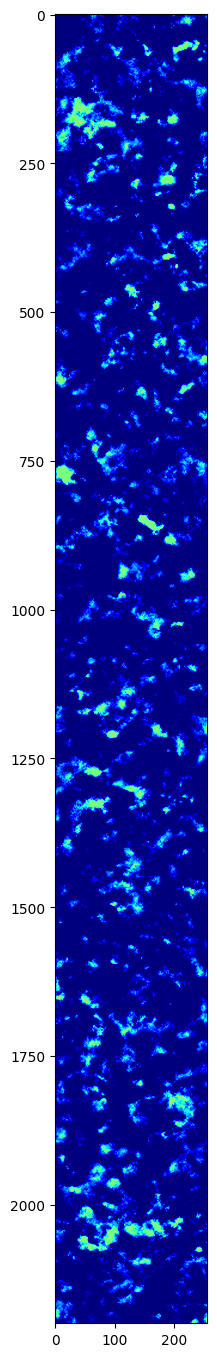

Elasped time:1.342
Iteration 00001    Loss 29.9758    PSNR -14.7677    SSIM 0.0025
Iteration 00002    Loss 30.4058    PSNR -14.8296    SSIM 0.0056
Iteration 00003    Loss 28.8445    PSNR -14.6006    SSIM 0.0130
Iteration 00004    Loss 28.8214    PSNR -14.5971    SSIM 0.0327
Iteration 00005    Loss 28.7563    PSNR -14.5873    SSIM 0.0431
Iteration 00006    Loss 28.7503    PSNR -14.5864    SSIM 0.0619
Iteration 00007    Loss 28.7438    PSNR -14.5854    SSIM 0.1016
Iteration 00008    Loss 28.7388    PSNR -14.5847    SSIM 0.1173
Iteration 00009    Loss 28.7388    PSNR -14.5847    SSIM 0.1436
Iteration 00010    Loss 28.7407    PSNR -14.5850    SSIM 0.1413
Elasped time:8.783
Iteration 00011    Loss 28.7383    PSNR -14.5846    SSIM 0.1498
Iteration 00012    Loss 28.7364    PSNR -14.5843    SSIM 0.1234
Iteration 00013    Loss 28.7356    PSNR -14.5842    SSIM 0.1123
Iteration 00014    Loss 28.7344    PSNR -14.5840    SSIM 0.1380
Iteration 00015    Loss 28.7342    PSNR -14.5840    SSIM 0.1610
It

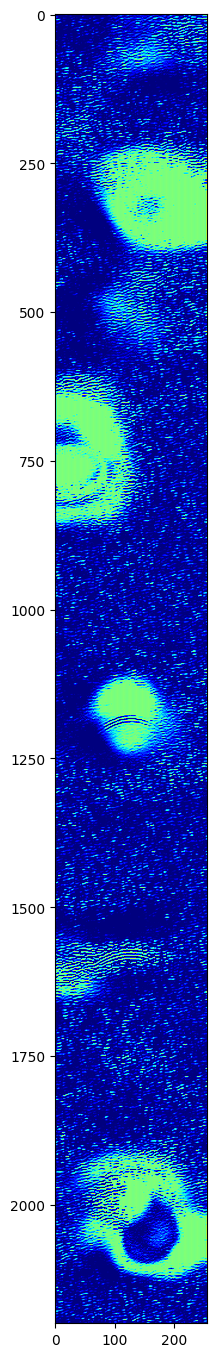

Elasped time:39.189
Iteration 00051    Loss 25.9771    PSNR -14.1459    SSIM 0.0101
Iteration 00052    Loss 25.4872    PSNR -14.0632    SSIM 0.0069
Iteration 00053    Loss 23.5362    PSNR -13.7174    SSIM 0.0050
Iteration 00054    Loss 22.1863    PSNR -13.4608    SSIM 0.0572
Iteration 00055    Loss 20.8356    PSNR -13.1881    SSIM 0.0119
Iteration 00056    Loss 19.7911    PSNR -12.9647    SSIM 0.0100
Iteration 00057    Loss 18.8323    PSNR -12.7490    SSIM 0.0083
Iteration 00058    Loss 17.9347    PSNR -12.5369    SSIM 0.0105
Iteration 00059    Loss 17.4013    PSNR -12.4058    SSIM 0.0119
Iteration 00060    Loss 17.0155    PSNR -12.3085    SSIM 0.0114
Elasped time:46.67
Iteration 00061    Loss 15.8714    PSNR -12.0062    SSIM 0.0145
Iteration 00062    Loss 15.2589    PSNR -11.8352    SSIM 0.0101
Iteration 00063    Loss 14.2347    PSNR -11.5335    SSIM 0.0090
Iteration 00064    Loss 13.8204    PSNR -11.4052    SSIM 0.0079
Iteration 00065    Loss 13.1137    PSNR -11.1773    SSIM 0.0068
I

In [ ]:
# for 256
i = 0
psnr_history = [] 
loss_history = [] 
ssim_history = []
loss_whole_history = []
def closure():
    
    global i
    
    if param_noise:
        for n in [x for x in net.parameters() if len(x.size()) == 4]:
            n = n + n.detach().clone().normal_() * n.std() / 50
    
    net_input = net_input_saved
    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)
        
        
    out_temp = net(net_input)    # output of network (1, 1, H, W)
    x_reshaped = out_temp.view(1, 1, 2200, 128, 2)
    x_summed = torch.sum(x_reshaped, dim=-1)
    out = torch.zeros_like(out_temp)
    out[:, :, :, ::2] = x_summed #一行有值一行為零
    total_loss = mse(out * mask_var, img_var * mask_var)
    # whole loss
    whole_loss = mse(out_temp, template_var)
    total_loss.backward()
    psnr = compare_psnr(img_np, torch_to_np(out), data_range = 1.0)
    ssim = compare_ssim(img_np[0,:], torch_to_np(out)[0,:], data_range = 1.0)
    # History
    loss_history.append(total_loss.item())
    psnr_history.append(psnr)
    ssim_history.append(ssim)
    loss_whole_history.append(whole_loss.item())

    # print ('Iteration %05d    Loss %f    PSNR %f    SSIM %f' % (i, total_loss.item(), psnr, ssim), '\r', end='')
    print(f'Iteration {i:05d}    Loss {total_loss.item():.4f}    PSNR {psnr:.4f}    SSIM {ssim:.4f}')


    if  PLOT and i % show_every == 0:
        out_np = torch_to_np(out)   
        plot_image_grid([np.clip(out_np, 0, 1)], factor=figsize, nrow=1)
    if i % save_every == 0:
        out_np = torch_to_np(out)[0,:]
        out_log_np[i//save_every, :, :] = out_np
        print(f'Elasped time:{round(time.time() - start_time, 3)}')
        time_log_np[0, i//save_every] = round(time.time() - start_time, 3)
    i += 1
    return total_loss

start_time = time.time()
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()
p = get_params(OPT_OVER, net, net_input)
# optimize(OPTIMIZER, p, closure, LR, 100)
optimize(OPTIMIZER, p, closure, LR, num_iter)

Show the final output of DIP

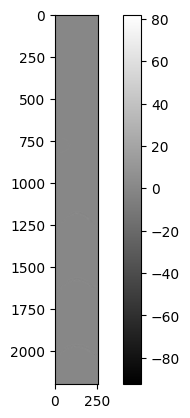

In [43]:
img_out = torch_to_np(net(net_input))[0,:]
plt.imshow(img_out, cmap='gray')
plt.colorbar()

In [44]:
print(img_out.shape)

(2200, 256)


In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(img_template, cmap='gray')
plt.colorbar()
plt.title('Reference')
plt.subplot(1, 2, 2)
plt.imshow(img_out, cmap='gray')
plt.colorbar()
plt.title('Reconstructed')

In [ ]:
torch.cuda.empty_cache()

In [ ]:
sio.savemat("reconstruct_loss384.mat", {"result":img_out})

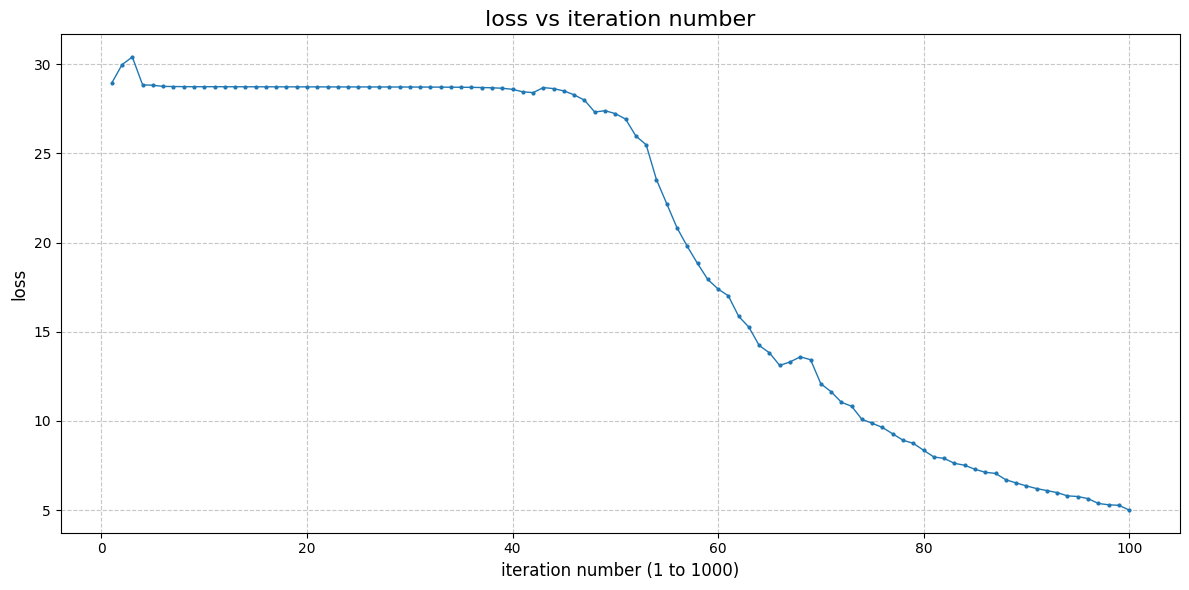

In [45]:
# 作圖
import matplotlib.pyplot as plt
import numpy as np

# 2. 準備X軸數據 (元素的順序)
# 我們需要從1到1000的序列
x_axis = np.arange(1, len(loss_history)+1)
# x_axis = np.arange(201, len(loss_history[200:]) + 201)

# 3. 繪製折線圖
plt.figure(figsize=(12, 6)) # 設定圖表大小，讓它看起來更清晰
plt.plot(x_axis, loss_history, linestyle='-', marker='o', markersize=2, linewidth=1) # 繪製折線圖
# plt.plot(x_axis, loss_history[200:], linestyle='-', marker='o', markersize=2, linewidth=1) # 繪製折線圖

# 4. 添加標題和軸標籤
plt.title('loss vs iteration number', fontsize=16) # 圖表標題
plt.xlabel('iteration number (1 to 1000)', fontsize=12) # X軸標籤
plt.ylabel('loss', fontsize=12) # Y軸標籤

# 5. 添加網格線 (可選，讓數據點更容易對齊)
plt.grid(True, linestyle='--', alpha=0.7)

# 6. 顯示圖表
plt.tight_layout() # 自動調整佈局，防止標籤重疊
plt.show()

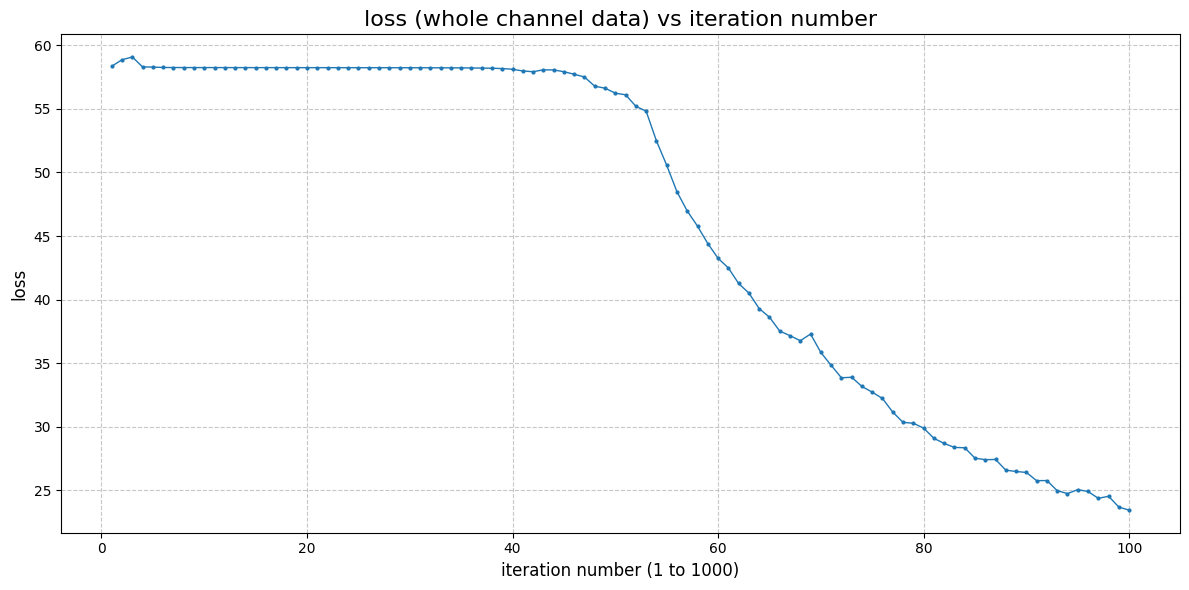

In [46]:
# plotting
import matplotlib.pyplot as plt
import numpy as np

# 2. 準備X軸數據 (元素的順序)
# 我們需要從1到1000的序列
x_axis = np.arange(1, len(loss_history) + 1)
# x_axis = np.arange(201, len(loss_history[200:]) + 201)

# 3. 繪製折線圖
plt.figure(figsize=(12, 6)) # 設定圖表大小，讓它看起來更清晰
plt.plot(x_axis, loss_whole_history, linestyle='-', marker='o', markersize=2, linewidth=1) # 繪製折線圖
# plt.plot(x_axis, loss_history[200:], linestyle='-', marker='o', markersize=2, linewidth=1) # 繪製折線圖

# 4. 添加標題和軸標籤
plt.title('loss (whole channel data) vs iteration number', fontsize=16) # 圖表標題
plt.xlabel('iteration number (1 to 1000)', fontsize=12) # X軸標籤
plt.ylabel('loss', fontsize=12) # Y軸標籤

# 5. 添加網格線 (可選，讓數據點更容易對齊)
plt.grid(True, linestyle='--', alpha=0.7)

# 6. 顯示圖表
plt.tight_layout() # 自動調整佈局，防止標籤重疊
plt.show()

In [49]:
out_np = np.expand_dims(img_out, 0)  # expand the downsampled image to 3D numpy array (1, H, W)
out_var = np_to_torch(img_out).type(dtype)
loss = mse(out_var, template_var)
print(loss.item())

23.23418426513672
